In [1]:
#TASK-1
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42)
print("Dataset Dimensions (rows, cols):", X.shape)
print("Missing values per column:\n", X.isnull().sum())
print("\nFirst 3 rows of target data:")
print(y_train.head(3))

Dataset Dimensions (rows, cols): (20640, 8)
Missing values per column:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

First 3 rows of target data:
14196    1.030
8267     3.821
17445    1.726
Name: MedHouseVal, dtype: float64


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standardized training features mean (approx 0):",
      round(X_train_scaled.mean(), 4))
print("Standardized training features std dev (approx 1):",
      round(X_train_scaled.std(), 4))

Standardized training features mean (approx 0): 0.0
Standardized training features std dev (approx 1): 1.0


In [3]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score                       : {r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 0.5332
Mean Squared Error (MSE)       : 0.5559
Root Mean Squared Error (RMSE) : 0.7456
R² Score                       : 0.5758


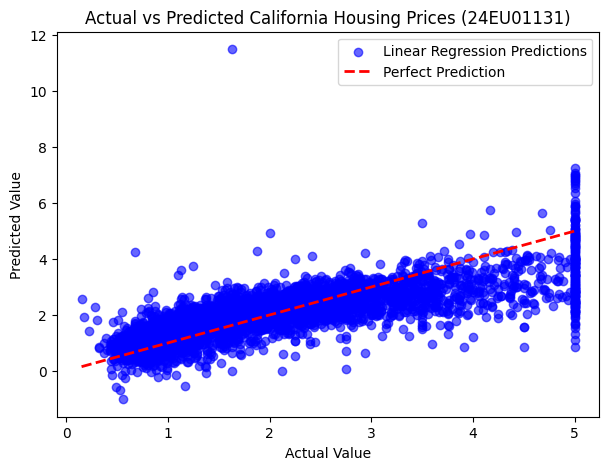

In [5]:

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred,color='blue',alpha=0.6,label='Linear Regression Predictions')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],
         'r--',lw=2,label='Perfect Prediction')
plt.title("Actual vs Predicted California Housing Prices (24EU01131)")
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.legend()
plt.show()

In [6]:
#TASK-2
from sklearn.svm import SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
svr_predictions = svr_model.predict(X_test_scaled)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)
print("Support Vector Regression Performance Metrics")
print("---------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {svr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {svr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {svr_rmse:.4f}")
print(f"R² Score                       : {svr_r2:.4f}")

Support Vector Regression Performance Metrics
---------------------------------------------
Mean Absolute Error (MAE)      : 0.3986
Mean Squared Error (MSE)       : 0.3570
Root Mean Squared Error (RMSE) : 0.5975
R² Score                       : 0.7276


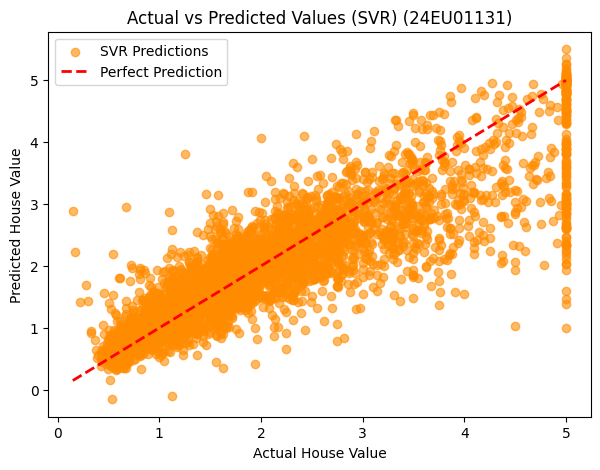

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test,svr_predictions,color='darkorange',alpha=0.6,label='SVR Predictions')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--',
         lw=2,label='Perfect Prediction')
plt.title("Actual vs Predicted Values (SVR) (24EU01131)")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.legend()
plt.show()


In [9]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [10]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)
print("Decision Tree Regression Performance Metrics")
print("--------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {dt_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {dt_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.4f}")
print(f"R² Score                       : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics
--------------------------------------------
Mean Absolute Error (MAE)      : 0.4547
Mean Squared Error (MSE)       : 0.4952
Root Mean Squared Error (RMSE) : 0.7037
R² Score                       : 0.6221


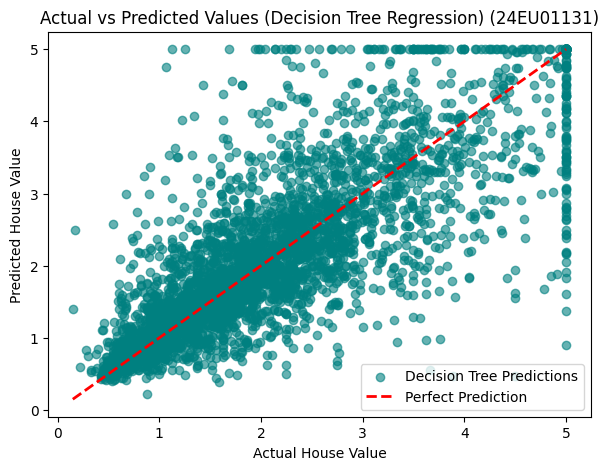

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,dt_predictions,color='teal',alpha=0.6,label='Decision Tree Predictions')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', lw=2,
         label='Perfect Prediction')
plt.title("Actual vs Predicted Values (Decision Tree Regression) (24EU01131)")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.legend()
plt.show()

In [12]:
comparison_df = pd.DataFrame({"Regression Model": ["Support Vector Regression",
        "Decision Tree Regression"],"MAE": [svr_mae,dt_mae],
    "RMSE": [
        svr_rmse,
        dt_rmse
    ],
    "R² Score": [
        svr_r2,
        dt_r2
    ]
})
print("\n--- Performance Comparison on California Housing Dataset ---")
print(comparison_df.to_string(index=False))


--- Performance Comparison on California Housing Dataset ---
         Regression Model      MAE     RMSE  R² Score
Support Vector Regression 0.398599 0.597498  0.727563
 Decision Tree Regression 0.454679 0.703729  0.622076


In [13]:
#TASK-3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
lr_mae = mean_absolute_error(y_test,y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)
performance = pd.DataFrame({ "Model": ["Linear Regression","Support Vector Regression",
        "Decision Tree Regression"
    ],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R² Score": [lr_r2, svr_r2, dt_r2]
})
print("Regression Model Performance Comparison")
print(performance)

Regression Model Performance Comparison
                       Model       MAE       MSE      RMSE  R² Score
0          Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Support Vector Regression  0.398599  0.357004  0.597498  0.727563
2   Decision Tree Regression  0.454679  0.495235  0.703729  0.622076


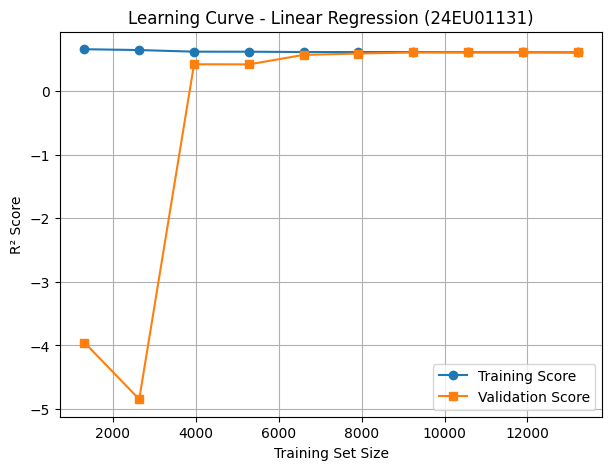

In [14]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
lr_model = LinearRegression()
train_sizes, train_scores, validation_scores = learning_curve(estimator=lr_model,X=X_train_scaled,
    y=y_train,train_sizes=np.linspace(0.1, 1.0, 10),cv=5,scoring='r2')
train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, validation_mean, marker='s', label="Validation Score")
plt.title("Learning Curve - Linear Regression (24EU01131)")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

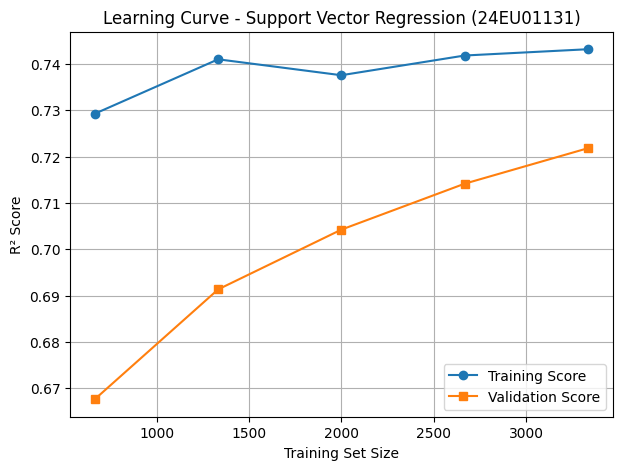

In [15]:
from sklearn.model_selection import learning_curve
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import numpy as np
X_train_svr = X_train_scaled[:5000]
y_train_svr = y_train.iloc[:5000]
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=svr_model,
    X=X_train_svr,
    y=y_train_svr,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring='r2',
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, validation_mean, marker='s', label='Validation Score')
plt.title("Learning Curve - Support Vector Regression (24EU01131)")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

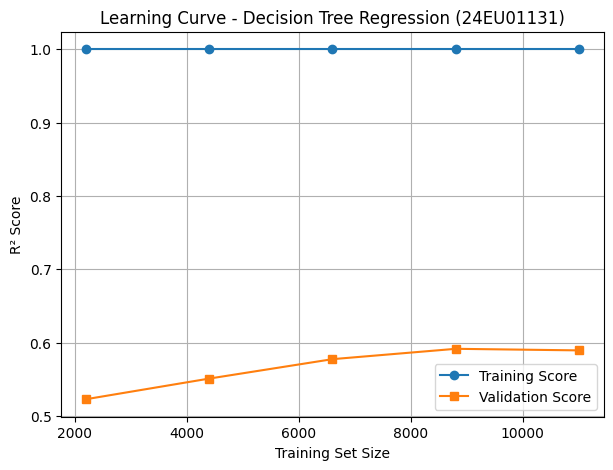

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
dt_model = DecisionTreeRegressor(random_state=42)
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=dt_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring='r2',
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, validation_mean, marker='s', label='Validation Score')
plt.title("Learning Curve - Decision Tree Regression (24EU01131)")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()